## Model

In [5]:
from utils import load_config, TrainModelPipeline

cfg = load_config("configs/phase_3.yaml")
cfg.pretrained_path = "out/fine_tune/checkpoint.pt"
cfg.data.max_samples = 1
cfg.data.sample_ratio = 1.0
cfg.data.eval_split_ratio = 0.0

pl = TrainModelPipeline(cfg)
pl.load_things()

Loading CSV from: /home/alief/prjkcad/data/text2cad/text2cad_v1.1.csv
Processing 1 rows to load JSON payloads...


100%|██████████| 1/1 [00:00<00:00, 699.05it/s]

Sampled 1 instances from the dataset based on the specified sample ratio of 1.0.



The following layers were not sharded: encoder.layer.*.intermediate.dense.bias, encoder.layer.*.attention.output.LayerNorm.weight, encoder.layer.*.attention.self.query.bias, encoder.layer.*.output.LayerNorm.bias, encoder.layer.*.attention.self.key.bias, encoder.layer.*.intermediate.dense.weight, encoder.layer.*.output.LayerNorm.weight, pooler.dense.bias, encoder.layer.*.attention.self.value.bias, encoder.layer.*.attention.self.value.weight, encoder.layer.*.attention.self.key.weight, pooler.dense.weight, embeddings.LayerNorm.weight, encoder.layer.*.output.dense.weight, encoder.layer.*.attention.self.query.weight, embeddings.word_embeddings.weight, encoder.layer.*.attention.output.LayerNorm.bias, embeddings.token_type_embeddings.weight, encoder.layer.*.output.dense.bias, encoder.layer.*.attention.output.dense.weight, embeddings.position_embeddings.weight, embeddings.LayerNorm.bias, encoder.layer.*.attention.output.dense.bias


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded model checkpoint from out/fine_tune/checkpoint.pt
Successfully loaded model checkpoint: diff on model output


Epoch  1/10 - loss: 4.3108
Epoch  2/10 - loss: 4.3843
Epoch  3/10 - loss: 4.2914
Epoch  4/10 - loss: 4.3465
Epoch  5/10 - loss: 4.1595
Epoch  6/10 - loss: 4.1808
Epoch  7/10 - loss: 4.1988
Epoch  8/10 - loss: 4.3367
Epoch  9/10 - loss: 4.3939
Epoch 10/10 - loss: 4.1517


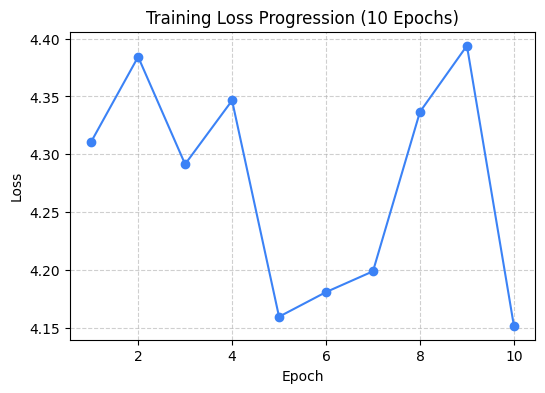

In [6]:
import torch
import matplotlib.pyplot as plt
from utils.trainer.dual_seq_cmdonly_trainer import _move_to_device

# ── Training 10 Epochs ──────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
wrapper = pl.wrapper
criterion = pl.criterion
optimizer = pl.optimizer

losses = []
for epoch in range(10):
    wrapper.model.train()
    epoch_loss = 0.0
    num_batches = 0
    for batch in pl.train_loader:
        batch = _move_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)
        
        # Forward pass
        res = wrapper.forward(batch, is_teacher_forcing=True)
        logits = res[0]
        
        if len(batch) == 4:
            input_ids, cmd_targets, arg_targets, attention_mask = batch
            arg_preds = res[2]
            loss = criterion(logits, cmd_targets, arg_preds, arg_targets)
        else:
            input_ids, cmd_targets, attention_mask = batch
            loss = criterion(logits, cmd_targets)
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(wrapper.model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += float(loss.detach().cpu().item())
        num_batches += 1
        
    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)
    print(f"Epoch {epoch+1:2d}/10 - loss: {avg_loss:.4f}")

# Plot progression
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), losses, marker='o', color='#3b82f6')
plt.title("Training Loss Progression (10 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [7]:
import pandas as pd
from utils.dual_seq import get_dualseq_schema
from utils.trainer.dual_seq_cmdonly_trainer import _move_to_device

# Get data batch for evaluation after training
raw_batch = next(iter(pl.train_loader))
batch = _move_to_device(raw_batch, device)

# Get predictions
wrapper.model.eval()
with torch.no_grad():
    res = wrapper.forward(batch, is_teacher_forcing=True)
    logits = res[0]
    preds = res[1]

# Extract schema details
schema = get_dualseq_schema()
id_to_cmd = schema['id_to_command']

# Logits shape: (B, T, V). Take first sample: (T, V)
lg = logits[0].float().cpu()
pr = preds[0].cpu().tolist()
tg = batch[1][0].cpu().tolist()

# Select several token classes for columns
logit_tokens = ["PAD", "EOS", "COOR", "FACE", "LOOP", "LINE", "CIRCLE", "EXTRUDE_NEW"]

rows = []
for t, (p, g, lg_t) in enumerate(zip(pr, tg, lg)):
    row = {
        'step': t,
        'pred_token': id_to_cmd.get(p, f'id{p}'),
        'gt_token': id_to_cmd.get(g, f'id{g}'),
    }
    for name in logit_tokens:
        token_id = schema['command_to_id'][name]
        row[name] = round(float(lg_t[token_id]), 4)
    rows.append(row)

df = pd.DataFrame(rows).set_index('step')
display(df)

,pred_token,gt_token,PAD,EOS,COOR,FACE,LOOP,LINE,CIRCLE,EXTRUDE_NEW
step,,,,,,,,,,
0,LINE,COOR,-3.7077,-0.5462,0.9578,2.2297,2.2969,8.5124,-0.1430,-0.9824
1,LINE,FACE,-3.7157,-0.5560,-0.0672,2.8564,2.3703,8.6547,-0.0709,-0.9760
2,LINE,LOOP,-3.8444,-0.5186,-0.2099,2.0617,2.9205,8.6104,-0.1367,-1.0132
3,LINE,LINE,-3.8183,-0.5388,-0.1961,2.0161,2.3068,8.9974,0.1820,-0.9091
4,LINE,LINE,-3.7349,-0.6147,-0.2861,1.9457,2.1492,9.1630,-0.0677,-0.8327
5,LINE,LINE,-3.7269,-0.5060,-0.3345,2.0376,2.0224,9.1905,-0.1267,-0.8540
6,LINE,LINE,-3.6941,-0.5328,-0.4278,1.9237,2.1189,9.1842,-0.1507,-0.8225
7,LINE,EXTRUDE_NEW,-3.7456,-0.4456,-0.4088,1.9133,2.1437,9.1646,-0.2096,-0.7148
8,LINE,EOS,-3.8354,-0.1329,-0.1667,2.0536,2.3635,8.9379,-0.1681,-0.9415


In [10]:
print(wrapper.model)

BaseModel(
  (encoder): PretrainedBERTEncoder(
    (encoder): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, out_features=7

## Renderer

### Direct OCC OpenGL Renderer vs Matplotlib Renderer

Below, we test the proposed offscreen rendering method using OpenCASCADE's native display pipeline (`init_display()`), comparing its performance and visual output with the matplotlib-based tessellated rendering.

In [5]:
from utils.data_utils import RefLoader
from utils.dual_seq import DualSeq
from utils import load_config
cfg_render = load_config("configs/experiment_1b.yaml")
cfg_render.data.max_samples = None  # ignore max_samples for debugging

loader = RefLoader(
    cfg_render.data.data_root,
    max_samples=cfg_render.data.get("max_samples", None)
)
df = loader.load()

dual_seq_list = DualSeq.from_text2cad_df(df)
show_ds = [ds for ds in dual_seq_list if ds.part_count > 1][:10]
print(f"Found {len(show_ds)} DualSeq instances with part_count > 1.")

Loading CSV from: /home/alief/prjkcad/data/text2cad/text2cad_v1.1.csv
Processing 176017 rows to load JSON payloads...


100%|██████████| 176017/176017 [00:17<00:00, 10003.12it/s]


Successfully created 175943/176017 DualSeq instances.
Found 10 DualSeq instances with part_count > 1.


In [9]:
from utils.render import render_dual_seq_to_img, render_to_image
from OCC.Core.BRepAlgoAPI import BRepAlgoAPI_Fuse

import numpy as np

for i, ds in enumerate(show_ds[:10]) :
    path = f"out/test_render/{i}_{ds.uid.split("/")[1]}.png"
    render_dual_seq_to_img(ds, path, with_str=True)
    print(f"OCC direct rendering complete! Saved to {path}")

####### 3D rendering pipe initialisation #####
Display3d class initialization starting ...
Aspect_DisplayConnection created.
OpenGl_GraphicDriver created.
V3d_Viewer created.
AIS_InteractiveContext created.
V3d_View created
Graphic3d_Camera created
Graphic3d_StructureManager created
Display3d class successfully initialized.
#########################################
OpenGl information:
  GLvendor: Mesa
  GLdevice: llvmpipe (LLVM 20.1.2, 256 bits)
  GLversion: 4.5 (Compatibility Profile) Mesa 25.2.8-0ubuntu0.24.04.2
  GLSLversion: 4.50
  Max texture size: 16384
  Max FBO dump size: 16384x16384
  Max combined texture units: 192
  Max MSAA samples: 4
  Viewport: 640x480
  Window buffer: RGB8 ALPHA0 DEPTH24 STENCIL8
  ResolutionRatio: 1
  FBO buffer: GL_SRGB8_ALPHA8 GL_DEPTH24_STENCIL8
OCC direct rendering complete! Saved to out/test_render/0_00351935.png
####### 3D rendering pipe initialisation #####
Display3d class initialization starting ...
Aspect_DisplayConnection created.
OpenGl_Graph

In [7]:
# imports for faces
from OCC.Core.gp import gp_Pnt, gp_Circ, gp_Ax2, gp_Dir
from OCC.Core.BRepBuilderAPI import (
    BRepBuilderAPI_MakeEdge,
    BRepBuilderAPI_MakeWire
)
from OCC.Core.GC import GC_MakeArcOfCircle
from OCC.Display.WebGl.jupyter_renderer import JupyterRenderer

# imports for extrusion
from OCC.Core.BRepBuilderAPI import BRepBuilderAPI_MakeFace
from OCC.Core.BRepPrimAPI import BRepPrimAPI_MakePrism
from OCC.Core.gp import gp_Vec

def extract_loops(cmds: list[str], args: list[dict]):
    """
    Extracts loops from a face
    """
    
    loops = []
    current_loop_cmds = []
    current_loop_args = []
    
    for cmd, arg in zip(cmds, args):
        if cmd == "LOOP":
            if current_loop_cmds:
                loops.append((current_loop_cmds, current_loop_args))
                current_loop_cmds = []
                current_loop_args = []
        else :
            current_loop_cmds.append(cmd)
            current_loop_args.append(arg)
        
    if current_loop_cmds:
        loops.append((current_loop_cmds, current_loop_args))

    return loops    

def extract_faces(cmds: list[str], args: list[dict]):
    """
    Extracts faces from a part, return a list of list of loops, each face is a list of loops, each loop is a tuple of (cmds, args)
    """
    
    faces = []
    current_face_cmds = []
    current_face_args = []
    
    for cmd, arg in zip(cmds, args):
        if cmd == "FACE":
            if current_face_cmds:
                loops = extract_loops(current_face_cmds, current_face_args)
                faces.append({
                    "loops": loops
                })
                current_face_cmds = []
                current_face_args = []
        else :
            current_face_cmds.append(cmd)
            current_face_args.append(arg)
    
    # last face
    if current_face_cmds:
        loops = extract_loops(current_face_cmds, current_face_args)
        faces.append({
            "loops": loops
        })

    return faces
   
def split_by_parts(cmds: list[str], args: list[dict]):
    """
    Splits the parts of a model
    
    From DualSeq, a part can be defined as a sequnce starting with a COOR command, followed by one or more FACE commands, and ending with an EXTRUDE command.
    
    This function splits the part by detecting only COOR commands as the start of a new part.
    
    Returns a list of dicts, where each dict corresponds to a part, with keys:
      - "coor"  : the COOR command args
      - "faces" : a list of faces, where each face is a list of loops
      - "extrude" : the EXTRUDE command args
    Also raises errors if the schema is not followed
    """
    
    parts = []
    current_part_cmds = []
    current_part_args = []
    current_coor_args = None
    
    for cmd, arg in zip(cmds, args):
        if cmd == "COOR" :
            if current_part_cmds:
                # push latest parts
                last_cmd = current_part_cmds[-1]
                last_arg = current_part_args[-1]
                
                if not last_cmd.startswith("EXTRUDE"):
                    raise ValueError(f"Invalid : a part does not end with EXTRUDE command, last command is {last_cmd} with args {last_arg}")
                
                extrude_type = last_cmd.split("_")[1] if "_" in last_cmd else None
                extrude_args = last_arg
                
                faces = extract_faces(current_part_cmds[:-1], current_part_args[:-1])
                parts.append({
                    "coor": current_coor_args,
                    "faces": faces,
                    "extrude": {
                        "type": extrude_type, "args": extrude_args
                    }
                })
            
            current_coor_args = arg
            current_part_cmds = []
            current_part_args = []
            
        # Use else to skip COOR command itself
        else :
            current_part_cmds.append(cmd)
            current_part_args.append(arg)
    
    # last
    if current_part_cmds:
        # push latest parts
        last_cmd = current_part_cmds[-1]
        last_arg = current_part_args[-1]
        
        if not last_cmd.startswith("EXTRUDE"):
            raise ValueError(f"Invalid : a part does not end with EXTRUDE command, last command is {last_cmd} with args {last_arg}")
        
        extrude_type = last_cmd.split("_")[1] if "_" in last_cmd else None
        extrude_args = last_arg
        
        faces = extract_faces(current_part_cmds[:-1], current_part_args[:-1])
        parts.append({
            "coor": current_coor_args,
            "faces": faces,
            "extrude": {
                "type": extrude_type, "args": extrude_args
            }
        })

    return parts


In [8]:
parts = split_by_parts(tds.cmds, tds.args)

import json
print(json.dumps(parts, indent=2))

NameError: name 'tds' is not defined

In [ ]:
def build_brep(dual_seq: DualSeq):
    parts = split_by_parts(dual_seq.cmds, dual_seq.args)
    brep_parts = []
    
    for part in parts:
        coor = part["coor"]
        faces = part["faces"]
        extrude = part.get("extrude", None)
        
        # Build faces with wires
        occ_faces = []

        for face in faces:
            loops = face["loops"]
            wires = []
            for loop_cmds, loop_args in loops:
                
                # Wire building scheme :
                # build on xy plane, so set a z=0 for all points
                wire_builder = BRepBuilderAPI_MakeWire()
                for cmd, arg in zip(loop_cmds, loop_args):
                    if cmd == "LINE":
                        p1 = gp_Pnt(arg["line_sx"], arg["line_sy"], 0)
                        p2 = gp_Pnt(arg["line_ex"], arg["line_ey"], 0)
                        edge = BRepBuilderAPI_MakeEdge(p1, p2).Edge()
                        wire_builder.Add(edge)
                    elif cmd == "CIRCLE":
                        center = gp_Pnt(arg["circle_cx"], arg["circle_cy"], 0)
                        radius = arg["circle_r"]
                        circ = gp_Circ(gp_Ax2(center, gp_Dir(0, 0, 1)), radius)
                        edge = BRepBuilderAPI_MakeEdge(circ).Edge()
                        wire_builder.Add(edge)
                    elif cmd == "ARC":
                        p1 = gp_Pnt(arg["arc_sx"], arg["arc_sy"], 0)
                        pm = gp_Pnt(arg["arc_mx"], arg["arc_my"], 0)
                        p2 = gp_Pnt(arg["arc_ex"], arg["arc_ey"], 0)
                        arc = GC_MakeArcOfCircle(p1, pm, p2).Value()
                        edge = BRepBuilderAPI_MakeEdge(arc).Edge()
                        wire_builder.Add(edge)
                wires.append(wire_builder.Wire())

            if not wires:
                continue

            # first wire = outer, rest = holes
            face_builder = BRepBuilderAPI_MakeFace(wires[0])
            for w in wires[1:]:
                face_builder.Add(w)

            occ_faces.append(face_builder.Face())

        # combine faces 
        if not occ_faces:
            continue

        base_face = occ_faces[0]
        for f in occ_faces[1:]:
            base_face = BRepBuilderAPI_MakeFace(base_face, f).Face()
        

        # --- get extrusion depth ---
        dtn = (
            extrude.get("args", {}).get("extrude_new_dtn")
            or extrude.get("args", {}).get("extrude_join_dtn")
            or extrude.get("args", {}).get("extrude_cut_dtn")
            or extrude.get("args", {}).get("extrude_intersect_dtn")
            or 0
        )
        
        # get extrusion type
        extrude_type = extrude.get("type", None)
        if extrude_type not in ["NEW", "JOIN", "CUT", "INTERSECT"]:
            raise ValueError(f"Invalid extrude type: {extrude_type}")
        
        # --- extrude ---
        vec = gp_Vec(0, 0, dtn)
        prism = BRepPrimAPI_MakePrism(base_face, vec).Shape()
        brep_parts.append({
            "coor": coor,
            "faces": faces,
            "extrude": extrude,
            "brep": prism,
        })
        
    # --- combine all parts into a single shape ---
    if not brep_parts:
        return None
    
    # For simplicity, return the first part (or you can implement a boolean union of all parts)
    return brep_parts[0]

        
        
        

In [ ]:
"""utils/render/render_img.py: Render OCC shape to isometric PNG using OCC display pipeline via Viewer3d."""
import os
from OCC.Display.OCCViewer import Viewer3d
from OCC.Core.gp import gp_Dir
from OCC.Core.Quantity import Quantity_Color, Quantity_NOC_WHITE, Quantity_TOC_RGB
from OCC.Core.V3d import V3d_DirectionalLight
from OCC.Extend.TopologyUtils import TopologyExplorer


def render_to_image_occ(shape, filepath: str, size=(512, 512), face_color_rgb=(0.2, 0.2, 0.2), edge_color_rgb=(0, 0, 0), show_face_boundary=True) -> None:
    """
    Render a TopoDS_Shape to a high-fidelity isometric PNG using Python-OCC's 
    internal OpenGL rendering pipeline via Viewer3d.
    """
    width, height = size
    viewer = Viewer3d()
    viewer.Create(phong_shading=True, create_default_lights=True)
    viewer.set_bg_gradient_color([255, 255, 255], [255, 255, 255])
    viewer.SetModeShaded()
    viewer.hide_triedron()
    viewer.EnableAntiAliasing()
    
    dir_light = V3d_DirectionalLight(gp_Dir(0, 0.5, -1), Quantity_Color(Quantity_NOC_WHITE))
    dir_light.SetEnabled(True)
    dir_light.SetIntensity(500.0)
    viewer.Viewer.AddLight(dir_light)
    viewer.Viewer.SetLightOn()

    viewer.default_drawer.EnableDrawHiddenLine()
    viewer.default_drawer.SetFaceBoundaryDraw(show_face_boundary)
    ais_context = viewer.GetContext()
    dc = ais_context.DeviationCoefficient()
    da = ais_context.DeviationAngle()
    factor = 10
    ais_context.SetDeviationCoefficient(dc / factor)
    ais_context.SetDeviationAngle(da / factor)
    topexp = TopologyExplorer(shape)
    for face in topexp.faces():
        if face is not None:
            viewer.DisplayShape(face, color=Quantity_Color(*face_color_rgb, Quantity_TOC_RGB))
    for edge in topexp.edges():
        if edge is not None:
            viewer.DisplayShape(edge, color=Quantity_Color(*edge_color_rgb, Quantity_TOC_RGB))
    viewer.FitAll()
    viewer.SetSize(width, height)
    os.makedirs(os.path.dirname(os.path.abspath(filepath)), exist_ok=True)
    viewer.View.Dump(str(filepath))


In [ ]:
test_brep = build_brep(tds)

test_out_filepath = "out/t.png"
render_to_image_occ(test_brep, test_out_filepath)

####### 3D rendering pipe initialisation #####
Display3d class initialization starting ...
Aspect_DisplayConnection created.
OpenGl_GraphicDriver created.
V3d_Viewer created.
AIS_InteractiveContext created.
V3d_View created
Graphic3d_Camera created
Graphic3d_StructureManager created
Xw_Window created.
Display3d class successfully initialized.
#########################################
OpenGl information:
  GLvendor: Mesa
  GLdevice: llvmpipe (LLVM 20.1.2, 256 bits)
  GLversion: 4.5 (Compatibility Profile) Mesa 25.2.8-0ubuntu0.24.04.2
  GLSLversion: 4.50
  Max texture size: 16384
  Max FBO dump size: 16384x16384
  Max combined texture units: 192
  Max MSAA samples: 4
  Viewport: 1024x768
  Window buffer: RGB8 ALPHA8 DEPTH24 STENCIL8
  ResolutionRatio: 1
  FBO buffer: GL_SRGB8_ALPHA8 GL_DEPTH24_STENCIL8


TypeError: in method 'new_AIS_Shape', argument 1 of type 'TopoDS_Shape const &'

## New Model Format

In [1]:
from models import BaseModel
from utils import Config

/home/alief/miniconda3/envs/kaggle/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.sparse import csr_matrix, issparse


In [2]:
cfg = Config.from_yaml("configs/sanity_c.yaml")
# {'encoder_type': 't5-small', 'cmd_decoder_type': 't5-small', 'args_decoder_type': 'torch', 'use_moe': True, 'moe_type': 'OnFFN', 'moe_conf': 'DeepSeek'}
cfg.model.encoder_type = "t5-small"
cfg.model.cmd_decoder_type = "t5-small"
cfg.model.args_decoder_type = "torch"
cfg.model.use_moe = True
cfg.model.moe_type = "OnFFN"
cfg.model.moe_conf = "DeepSeek"

In [5]:
from utils.dual_seq import get_dualseq_schema

schema = get_dualseq_schema()
vocab_size = schema["n_tokens"]
n_args = schema["n_args"]

model = BaseModel(cfg.model, vocab_size = vocab_size, n_args=n_args)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total params:", total_params)
print("Trainable params:", trainable_params)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Total params: 392786988
Trainable params: 392786988


## Model Configurations Enumeration

In [ ]:
# ── Enumerate all possible valid model configurations ─────────────────────
import pandas as pd
from models import BaseModel
from utils.pipeline.config import ModelConfig
from utils.dual_seq import get_dualseq_schema

schema = get_dualseq_schema()
vocab_size = schema["n_tokens"]
n_args = schema["n_args"]

def is_valid_config(cfg):
    d_model = cfg.d_model
    if d_model not in [512]:
        return False
    
    enc = cfg.encoder_type
    if enc not in ["t5-small"]:
        return False
    if enc == "t5-small" and d_model != 512:
        return False
    
    cmd_dec = cfg.cmd_decoder_type
    if cmd_dec not in ["torch", "sdpa", "t5-small", "mamba"]:
        return False
    if cmd_dec.startswith("t5-"):
        if cmd_dec == "t5-small" and d_model != 512:
            return False
        if cmd_dec == "t5-base" and d_model != 768:
            return False
        if cmd_dec == "t5-large" and d_model != 1024:
            return False
            
    is_cmd_only = cfg.is_cmd_only
    args_dec = cfg.args_decoder_type
    if is_cmd_only:
        if args_dec is not None:
            return False
    else:
        if args_dec is None:
            return False
        if args_dec not in ["torch", "sdpa", "t5-small", "mamba"]:
            return False
        if args_dec.startswith("t5-"):
            if args_dec == "t5-small" and d_model != 512:
                return False
            if args_dec == "t5-base" and d_model != 768:
                return False
            if args_dec == "t5-large" and d_model != 1024:
                return False
                
    moe_type = cfg.moe_type
    moe_conf = cfg.moe_conf
    
    # Mamba already has MoE built-in, so we don't allow additional MoE on top of it
    if cmd_dec == "mamba" or args_dec == "mamba":
        if moe_type is not None or moe_conf is not None:
            return False
    
    if (moe_type is None) != (moe_conf is None):
        return False
        
    if moe_type is not None:
        if moe_type not in ["OnFFN", "MoA"]:
            return False
        if moe_conf not in ["Switch", "Mixtral"]: # Currently removing deepseek configuration
            return False
            
        if moe_type == "MoA":
            if cmd_dec.startswith("t5-"):
                return False
            if not is_cmd_only and args_dec.startswith("t5-"):
                return False
                
    return True

# Hyperparameter lists
encoders = ["t5-small"]
decoders = ["torch", "sdpa", "t5-small", "mamba"]
moe_types = ["OnFFN", "MoA", None]
moe_confs = ["Switch", "Mixtral", None]
is_cmd_only_options = [True, False]

valid_configs = []

# Enumerate configurations
for enc in encoders:
    if enc == "t5-small":
        d_model = 512
    else:
        continue
        
    for cmd_dec in decoders:
        for is_cmd_only in is_cmd_only_options:
            args_decoders = [None] if is_cmd_only else decoders
            for args_dec in args_decoders:
                for moe_t in moe_types:
                    for moe_c in moe_confs:
                        cfg = ModelConfig(
                            is_pretrained=False,
                            max_new_cmds=84,
                            encoder_type=enc,
                            cmd_decoder_type=cmd_dec,
                            args_decoder_type=args_dec,
                            is_cmd_only=is_cmd_only,
                            d_model=d_model,
                            moe_type=moe_t,
                            moe_conf=moe_c
                        )
                        if is_valid_config(cfg):
                            
                            model = BaseModel(cfg, vocab_size=vocab_size, n_args=n_args)
                            a = sum(p.numel() for p in model.parameters())
                            b = sum(p.numel() for p in model.parameters() if p.requires_grad)
                            valid_configs.append((cfg, a, b))
                            del model

print(f"Total valid configurations found: {len(valid_configs)}")

# Create pandas DataFrame for nice presentation
df_configs = pd.DataFrame([
    {
        "Encoder": cfg.encoder_type,
        "d_model": cfg.d_model,
        "Cmd Decoder": cfg.cmd_decoder_type,
        "Args Decoder": cfg.args_decoder_type if cfg.args_decoder_type else "N/A",
        "Cmd Only": cfg.is_cmd_only,
        "MoE Type": cfg.moe_type if cfg.moe_type else "None",
        "MoE Conf": cfg.moe_conf if cfg.moe_conf else "None",
        "Total Params": a, 
        "Trainable Params": b
    }
    for cfg, a, b in valid_configs
])

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Total valid configurations found: 116


In [5]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

display(df_configs)

,Encoder,d_model,Cmd Decoder,Args Decoder,Cmd Only,MoE Type,MoE Conf,Total Params,Trainable Params
0,t5-small,512,torch,N/A,True,OnFFN,Switch,111535885,111535885
1,t5-small,512,torch,N/A,True,OnFFN,Mixtral,111535885,111535885
2,t5-small,512,torch,N/A,True,OnFFN,DeepSeek,178743053,178743053
3,t5-small,512,torch,N/A,True,MoA,Switch,111595277,111595277
4,t5-small,512,torch,N/A,True,MoA,Mixtral,111595277,111595277
5,t5-small,512,torch,N/A,True,MoA,DeepSeek,178867981,178867981
6,t5-small,512,torch,N/A,True,None,None,52727565,52727565
7,t5-small,512,torch,torch,False,OnFFN,Switch,187759916,187759916
8,t5-small,512,torch,torch,False,OnFFN,Mixtral,187759916,187759916
9,t5-small,512,torch,torch,False,OnFFN,DeepSeek,322174252,322174252


In [7]:
cfg = ModelConfig(
    is_pretrained=False,
    max_new_cmds=84,
    encoder_type='t5-small',
    cmd_decoder_type='t5-small',
    args_decoder_type='t5-small',
    is_cmd_only=False,
    d_model=512,
    moe_type='OnFFN',
    moe_conf='DeepSeek'
)

model = BaseModel(cfg, vocab_size=vocab_size, n_args=n_args)
print(model)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

BaseModel(
  (encoder): PretrainedT5Encoder(
    (encoder): T5Stack(
      (embed_tokens): Embedding(32128, 512)
      (block): ModuleList(
        (0): T5Block(
          (layer): ModuleList(
            (0): T5LayerSelfAttention(
              (SelfAttention): T5Attention(
                (q): Linear(in_features=512, out_features=512, bias=False)
                (k): Linear(in_features=512, out_features=512, bias=False)
                (v): Linear(in_features=512, out_features=512, bias=False)
                (o): Linear(in_features=512, out_features=512, bias=False)
                (relative_attention_bias): Embedding(32, 8)
              )
              (layer_norm): T5LayerNorm()
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (1): T5LayerFF(
              (DenseReluDense): T5DenseActDense(
                (wi): Linear(in_features=512, out_features=2048, bias=False)
                (wo): Linear(in_features=2048, out_features=512, bias=False)
      

## Custom DualSeq Rendering Verification
This section verifies that the rendering pipeline works correctly for basic geometries and multi-part assemblies with Boolean joins.

In [ ]:
from utils.render import render_dual_seq_to_img
from utils.dual_seq import DualSeq

def create_dual_seq(uid, cmds, args, descriptions=None):
    ds = DualSeq.__new__(DualSeq)
    ds.uid = uid
    ds.cmds = cmds
    ds.args = args
    ds.descriptions = descriptions or {}
    return ds

descriptions = {
    "abstract": "A box with a small cylinder fuzed on the top face.",
    "beginner": "This is a simple two-part body. First, we create a 3D rectangular box of size 1x1x1. Then, we join a cylinder of radius 0.3 and height 0.5 on top of it.",
    "intermediate": "A fuzed assembly of a 1x1x1 cube and a 0.3 radius cylinder of height 0.5 centered at (0.5, 0.5) on the cube's top surface.",
    "expert": "Extrude a 1x1 square to depth 1.0 along the local Z axis. Fuse a circular profile (radius 0.3) extruded along local Z direction (offset tx=0, ty=0, tz=1)."
}

# 1. Example 1: A Cube
cube_ds = create_dual_seq(
    uid="test/cube",
    cmds=[
        "COOR", "FACE", "LOOP",
        "LINE", "LINE", "LINE", "LINE",
        "EXTRUDE_NEW"
    ],
    args=[
        {'coor_euax': 0.0, 'coor_euay': 0.0, 'coor_euaz': 0.0, 'coor_tx': 0.0, 'coor_ty': 0.0, 'coor_tz': 0.0},
        {}, {},
        {'line_sx': 0.0, 'line_sy': 0.0, 'line_ex': 1.0, 'line_ey': 0.0},
        {'line_sx': 1.0, 'line_sy': 0.0, 'line_ex': 1.0, 'line_ey': 1.0},
        {'line_sx': 1.0, 'line_sy': 1.0, 'line_ex': 0.0, 'line_ey': 1.0},
        {'line_sx': 0.0, 'line_sy': 1.0, 'line_ex': 0.0, 'line_ey': 0.0},
        {'extrude_new_dtn': 1.0, 'extrude_new_don': 0.0, 'extrude_new_scale': 1.0}
    ],
    descriptions=descriptions
)

# 2. Example 2: A Cylinder
cylinder_ds = create_dual_seq(
    uid="test/cylinder",
    cmds=[
        "COOR", "FACE", "LOOP",
        "CIRCLE",
        "EXTRUDE_NEW"
    ],
    args=[
        {'coor_euax': 0.0, 'coor_euay': 0.0, 'coor_euaz': 0.0, 'coor_tx': 0.0, 'coor_ty': 0.0, 'coor_tz': 0.0},
        {}, {},
        {'circle_cx': 0.5, 'circle_cy': 0.5, 'circle_r': 0.5},
        {'extrude_new_dtn': 1.0, 'extrude_new_don': 0.0, 'extrude_new_scale': 1.0}
    ],
    descriptions=descriptions
)

# 3. Example 3: Two-part body (Cube with a cylinder on top)
two_part_ds = create_dual_seq(
    uid="test/cube_and_cylinder",
    cmds=[
        # Part 1: Cube
        "COOR", "FACE", "LOOP",
        "LINE", "LINE", "LINE", "LINE",
        "EXTRUDE_NEW",
        # Part 2: Cylinder at the top (z = 1.0)
        "COOR", "FACE", "LOOP",
        "CIRCLE",
        "EXTRUDE_JOIN"
    ],
    args=[
        # Part 1: Cube Coor & Face & Extrude
        {'coor_euax': 0.0, 'coor_euay': 0.0, 'coor_euaz': 0.0, 'coor_tx': 0.0, 'coor_ty': 0.0, 'coor_tz': 0.0},
        {}, {},
        {'line_sx': 0.0, 'line_sy': 0.0, 'line_ex': 1.0, 'line_ey': 0.0},
        {'line_sx': 1.0, 'line_sy': 0.0, 'line_ex': 1.0, 'line_ey': 1.0},
        {'line_sx': 1.0, 'line_sy': 1.0, 'line_ex': 0.0, 'line_ey': 1.0},
        {'line_sx': 0.0, 'line_sy': 1.0, 'line_ex': 0.0, 'line_ey': 0.0},
        {'extrude_new_dtn': 1.0, 'extrude_new_don': 0.0, 'extrude_new_scale': 1.0},
        # Part 2: Cylinder Coor (z = 1.0) & Face & Extrude
        {'coor_euax': 0.0, 'coor_euay': 0.0, 'coor_euaz': 0.0, 'coor_tx': 0.0, 'coor_ty': 0.0, 'coor_tz': 1.0},
        {}, {},
        {'circle_cx': 0.5, 'circle_cy': 0.5, 'circle_r': 0.3},
        {'extrude_join_dtn': 0.5, 'extrude_join_don': 0.0, 'extrude_join_scale': 1.0}
    ],
    descriptions=descriptions
)

# Render examples with their description levels
render_dual_seq_to_img(cube_ds, "out/test_render/example_cube.png", with_str=True, with_desc="abstract")
print("Cube rendered!")
render_dual_seq_to_img(cylinder_ds, "out/test_render/example_cylinder.png", with_str=True, with_desc="intermediate")
print("Cylinder rendered!")
render_dual_seq_to_img(two_part_ds, "out/test_render/example_cube_cylinder.png", with_str=True, with_desc="beginner")
print("Two-part shape (Cube + Cylinder) rendered!")



## Shape Evaluation: Invalidity Rate (IR) & Chamfer Distance (CD)

This section tests the two new shape-level metrics:
- **IR (Invalidity Rate)**: fraction of shapes that fail to render.
- **CD (Chamfer Distance)**: mean bidirectional nearest-neighbour distance
  between point clouds sampled from two OCC shapes.

We use three hand-crafted DualSeq examples:
1. **Identical shapes** – cube + cylinder on top vs. the same → CD ≈ 0, IR = 0
2. **Different shapes** – cube vs. cylinder → CD > 0
3. **Scale difference** – cube vs. smaller cube → small but non-zero CD


In [2]:
from utils.others import make_cube, make_cylinder_on_top, make_cylinder

print('Shape builder helpers imported.')

### Invalidity Rate (IR)

IR counts `None` entries in a list of shapes, divided by total count.
We simulate one invalid shape by including `None` in the list.


In [3]:
from utils.evaluate import invalidity_rate_from_shapes

shape_a = make_cube(1.0)               # valid
shape_b = make_cylinder_on_top()       # valid
shape_c = make_cylinder()              # valid

# All-valid batch → IR should be 0.0
ir_all_valid = invalidity_rate_from_shapes([shape_a, shape_b, shape_c])
print(f'IR (all valid):          {ir_all_valid:.4f}   ← expected 0.0')

# One invalid shape (None) out of 4 → IR should be 0.25
ir_one_invalid = invalidity_rate_from_shapes([shape_a, None, shape_b, shape_c])
print(f'IR (1 invalid out of 4): {ir_one_invalid:.4f}   ← expected 0.25')

# All invalid → IR should be 1.0
ir_all_invalid = invalidity_rate_from_shapes([None, None])
print(f'IR (all invalid):        {ir_all_invalid:.4f}   ← expected 1.0')


IR (all valid):          0.0000   ← expected 0.0
IR (1 invalid out of 4): 0.2500   ← expected 0.25
IR (all invalid):        1.0000   ← expected 1.0


### Chamfer Distance (CD)

CD between identical shapes should be ≈ 0.
CD between dissimilar shapes should be > 0.


In [4]:
from utils.evaluate import chamfer_distance_from_shapes

# Build the three test shapes
cube          = make_cube(1.0)           # 1×1×1 cube
cube_cyl_top  = make_cylinder_on_top()   # 1×1×1 cube + cylinder on top
cylinder      = make_cylinder(0.5, 1.0)  # plain cylinder
small_cube    = make_cube(0.5)           # 0.5×0.5×0.5 cube

n_u, n_v = 20, 20

# 1. Identical shapes: cube+cyl vs cube+cyl → CD ≈ 0
cd_identical = chamfer_distance_from_shapes(cube_cyl_top, cube_cyl_top, n_u=n_u, n_v=n_v)
print(f'CD (cube+cyl  vs  cube+cyl [identical]): {cd_identical:.6f}  ← expected ~0')

# 2. Different shapes: cube vs cylinder → CD > 0
cd_diff = chamfer_distance_from_shapes(cube, cylinder, n_u=n_u, n_v=n_v)
print(f'CD (cube      vs  cylinder):             {cd_diff:.6f}  ← expected > 0')

# 3. Scale difference: cube vs smaller cube → small but non-zero CD
cd_scale = chamfer_distance_from_shapes(cube, small_cube, n_u=n_u, n_v=n_v)
print(f'CD (cube      vs  small_cube):           {cd_scale:.6f}  ← expected > 0 but < CD_diff')


CD (cube+cyl  vs  cube+cyl [identical]): 0.000000  ← expected ~0
CD (cube      vs  cylinder):             0.611428  ← expected > 0
CD (cube      vs  small_cube):           0.501703  ← expected > 0 but < CD_diff


### Raw Chamfer Distance on numpy point clouds

Quick sanity check: using `chamfer_distance` directly on hand-crafted point clouds.


In [5]:
import numpy as np
from utils.evaluate import chamfer_distance

# Identical point clouds → CD = 0
pts = np.random.rand(100, 3)
cd_same = chamfer_distance(pts, pts)
print(f'CD (A == B):        {cd_same:.6f}  ← expected 0.0')

# Shifted point cloud → CD = shift magnitude
shift = 1.0
pts_shifted = pts + shift
cd_shifted = chamfer_distance(pts, pts_shifted)
print(f'CD (A shifted {shift}): {cd_shifted:.6f}  ← expected ~{shift:.1f}')


CD (A == B):        0.000000  ← expected 0.0
CD (A shifted 1.0): 2.208248  ← expected ~1.0


### Visualizing Shapes and Their Chamfer Distance

Below, we render isometric views of shape pairs and display their corresponding Chamfer Distance.

In [6]:
from utils.others import visualize_pair

# Visualize the comparison pairs
print("Visualizing comparison pairs...")
visualize_pair(cube_cyl_top, cube_cyl_top, "cube_cyl_top", "cube_cyl_top")
visualize_pair(cube, cylinder, "cube", "cylinder")
visualize_pair(cube, small_cube, "cube", "small_cube")